In [1]:
# =========================================================
# Day 6. 앙상블 / AutoML 핵심 실습
# 파일: supervised_label_cn7.csv
# 목표: baseline vs ensemble vs 간단 AutoML 비교
# =========================================================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [3]:
# ---------------------------------------------------------
# 1. 데이터 불러오기
# ---------------------------------------------------------
df = pd.read_csv("supervised_label_cn7.csv")

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("=== 데이터 상위 5행 ===")
display(df.head())

print("\n=== PassOrFail 분포 ===")
display(df["PassOrFail"].value_counts().sort_index())

=== 데이터 상위 5행 ===


,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
1,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
2,0,9.58,4.46,16.90,59.580002,7.13,653.409973,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,67.500000,25.000000,27.6
3,0,9.58,4.46,16.92,59.560001,7.13,653.409973,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,67.000000,25.000000,27.6
4,0,9.57,4.45,16.91,59.520000,7.14,653.409973,68.830002,647.98999,55.700001,30.799999,292.500000,141.600006,136.399994,37.099998,59.099998,275.700012,274.899994,274.799988,270.799988,255.399994,230.100006,66.699997,24.799999,27.5



=== PassOrFail 분포 ===


PassOrFail
0    6697
1      39
Name: count, dtype: int64

In [4]:
# ---------------------------------------------------------
# 2. 입력 / 정답 분리
# ---------------------------------------------------------
X = df.drop(columns=["PassOrFail"])
y = df["PassOrFail"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n=== train / test 크기 ===")
print(X_train.shape, X_test.shape)


=== train / test 크기 ===
(5388, 24) (1348, 24)


In [5]:
# ---------------------------------------------------------
# 3. 평가 함수
# ---------------------------------------------------------
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, zero_division=0)

    print(f"\n=== {name} ===")
    print("Accuracy:", round(acc, 4))
    print("F1-score:", round(f1, 4))
    print(classification_report(y_test, pred, zero_division=0))

    return {
        "name": name,
        "model": model,
        "pred": pred,
        "accuracy": acc,
        "f1": f1
    }

In [6]:
# ---------------------------------------------------------
# 4. Baseline 모델
# ---------------------------------------------------------
baseline_model = LogisticRegression(max_iter=3000, random_state=42)
result_baseline = evaluate_model(baseline_model, "Baseline - Logistic Regression")


=== Baseline - Logistic Regression ===
Accuracy: 0.9978
F1-score: 0.7692
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



In [7]:
# ---------------------------------------------------------
# 5. Ensemble 1 - Random Forest
# ---------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
result_rf = evaluate_model(rf_model, "Ensemble - Random Forest")


=== Ensemble - Random Forest ===
Accuracy: 0.9955
F1-score: 0.625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



In [8]:
# ---------------------------------------------------------
# 6. Ensemble 2 - Gradient Boosting
# ---------------------------------------------------------
gb_model = GradientBoostingClassifier(random_state=42)
result_gb = evaluate_model(gb_model, "Ensemble - Gradient Boosting")


=== Ensemble - Gradient Boosting ===
Accuracy: 0.9955
F1-score: 0.625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



In [9]:
# ---------------------------------------------------------
# 7. Ensemble 3 - Voting
# ---------------------------------------------------------
voting_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=3000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
        ("dt", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ],
    voting="hard"
)

result_voting = evaluate_model(voting_model, "Ensemble - Voting")


=== Ensemble - Voting ===
Accuracy: 0.9955
F1-score: 0.625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       0.62      0.62      0.62         8

    accuracy                           1.00      1348
   macro avg       0.81      0.81      0.81      1348
weighted avg       1.00      1.00      1.00      1348



In [10]:
# ---------------------------------------------------------
# 8. Ensemble 4 - Stacking
# ---------------------------------------------------------
stacking_model = StackingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=3000, random_state=42)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")),
        ("dt", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ],
    final_estimator=LogisticRegression(max_iter=3000, random_state=42)
)

result_stacking = evaluate_model(stacking_model, "Ensemble - Stacking")


=== Ensemble - Stacking ===
Accuracy: 0.9978
F1-score: 0.7692
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1340
           1       1.00      0.62      0.77         8

    accuracy                           1.00      1348
   macro avg       1.00      0.81      0.88      1348
weighted avg       1.00      1.00      1.00      1348



In [11]:
# ---------------------------------------------------------
# 9. 비교표
# ---------------------------------------------------------
compare_df = pd.DataFrame([
    {"model": result_baseline["name"], "accuracy": result_baseline["accuracy"], "f1": result_baseline["f1"]},
    {"model": result_rf["name"], "accuracy": result_rf["accuracy"], "f1": result_rf["f1"]},
    {"model": result_gb["name"], "accuracy": result_gb["accuracy"], "f1": result_gb["f1"]},
    {"model": result_voting["name"], "accuracy": result_voting["accuracy"], "f1": result_voting["f1"]},
    {"model": result_stacking["name"], "accuracy": result_stacking["accuracy"], "f1": result_stacking["f1"]}
]).sort_values("f1", ascending=False)

print("\n=== 모델 비교표 ===")
display(compare_df)


=== 모델 비교표 ===


,model,accuracy,f1
0,Baseline - Logistic Regression,0.997774,0.769231
4,Ensemble - Stacking,0.997774,0.769231
1,Ensemble - Random Forest,0.995549,0.625000
2,Ensemble - Gradient Boosting,0.995549,0.625000
3,Ensemble - Voting,0.995549,0.625000



=== 최고 모델 ===
Baseline - Logistic Regression


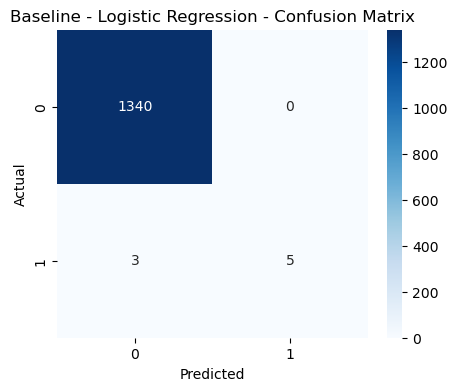

In [12]:
# ---------------------------------------------------------
# 10. 최고 모델 confusion matrix
# ---------------------------------------------------------
best_result = sorted(
    [result_baseline, result_rf, result_gb, result_voting, result_stacking],
    key=lambda x: x["f1"],
    reverse=True
)[0]

print("\n=== 최고 모델 ===")
print(best_result["name"])

cm = confusion_matrix(y_test, best_result["pred"])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_result['name']} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


=== 중요 변수 Top 10 ===


,feature,importance
6,Plasticizing_Position,0.167322
8,Max_Injection_Speed,0.088994
23,Mold_Temperature_4,0.073759
22,Mold_Temperature_3,0.067470
5,Cushion_Position,0.060012
1,Filling_Time,0.058332
0,Injection_Time,0.057484
12,Max_Switch_Over_Pressure,0.057357
10,Average_Screw_RPM,0.052556
4,Clamp_Close_Time,0.049314


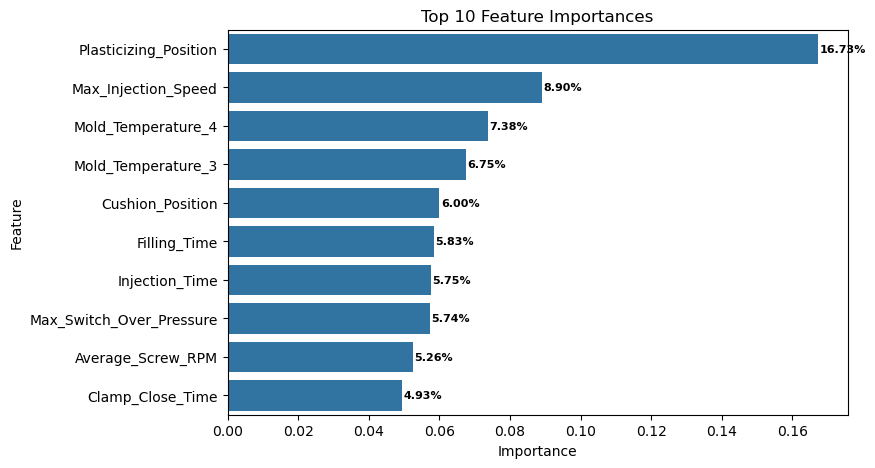

In [13]:
# ---------------------------------------------------------
# 11. 중요 변수 확인
#    - 트리 기반 모델일 때만 가능
# ---------------------------------------------------------
if hasattr(result_rf["model"], "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": X.columns,
        "importance": result_rf["model"].feature_importances_
    }).sort_values("importance", ascending=False)

    print("\n=== 중요 변수 Top 10 ===")
    display(importance_df.head(10))

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(data=importance_df.head(10), x="importance", y="feature")
    for i in ax.containers:
        ax.bar_label(i, fmt="{:.2%}", label_type='edge', padding=1, fontsize=8, color="black", fontweight="bold")
    plt.title("Top 10 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


=== 간단 AutoML 결과표 ===


,model,accuracy,f1
0,LogisticRegression,0.997774,0.769231
1,DecisionTree,0.995549,0.625000
2,RandomForest,0.995549,0.625000
3,GradientBoosting,0.995549,0.625000


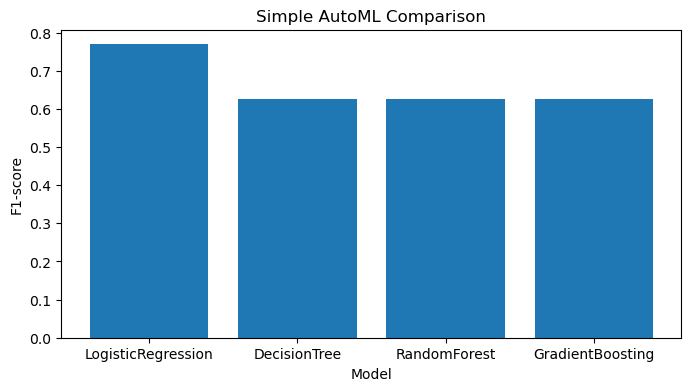

In [14]:
# ---------------------------------------------------------
# 12. 간단 AutoML 스타일 비교
#    - 여러 모델을 자동으로 돌려 결과만 비교
# ---------------------------------------------------------
candidate_models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

automl_results = []

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    automl_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0)
    })

automl_df = pd.DataFrame(automl_results).sort_values("f1", ascending=False)

print("\n=== 간단 AutoML 결과표 ===")
display(automl_df)

plt.figure(figsize=(8, 4))
plt.bar(automl_df["model"], automl_df["f1"])
plt.title("Simple AutoML Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.show()

In [15]:
# ---------------------------------------------------------
# 13. 발표용 요약 출력
# ---------------------------------------------------------
best_model_row = compare_df.iloc[0]

print("\n=== 발표용 한 줄 요약 ===")
print(f"가장 좋은 모델은 '{best_model_row['model']}' 이며, "
      f"Accuracy는 {best_model_row['accuracy']:.4f}, "
      f"F1-score는 {best_model_row['f1']:.4f} 입니다.")


=== 발표용 한 줄 요약 ===
가장 좋은 모델은 'Baseline - Logistic Regression' 이며, Accuracy는 0.9978, F1-score는 0.7692 입니다.


In [16]:
# ---------------------------------------------------------
# 14. 워크숍 질문
# ---------------------------------------------------------
print("\n=== 워크숍 질문 ===")
print("1. baseline 대비 가장 좋아진 모델은 무엇인가?")
print("2. ensemble이 항상 baseline보다 좋은가?")
print("3. Voting과 Stacking의 차이는 무엇인가?")
print("4. 중요 변수는 무엇인가?")
print("5. 현업에서는 어떤 모델을 추천할 것인가?")


=== 워크숍 질문 ===
1. baseline 대비 가장 좋아진 모델은 무엇인가?
2. ensemble이 항상 baseline보다 좋은가?
3. Voting과 Stacking의 차이는 무엇인가?
4. 중요 변수는 무엇인가?
5. 현업에서는 어떤 모델을 추천할 것인가?


In [17]:
# ---------------------------------------------------------
# 15. 최종 정리
# ---------------------------------------------------------
print("\n=== 오늘 실습 정리 ===")
print("1. baseline 모델을 만들었다.")
print("2. Random Forest, Gradient Boosting, Voting, Stacking을 비교했다.")
print("3. 간단 AutoML 스타일로 여러 모델을 자동 비교했다.")
print("4. 중요 변수를 해석했다.")
print("5. 발표용 비교표까지 정리했다.")


=== 오늘 실습 정리 ===
1. baseline 모델을 만들었다.
2. Random Forest, Gradient Boosting, Voting, Stacking을 비교했다.
3. 간단 AutoML 스타일로 여러 모델을 자동 비교했다.
4. 중요 변수를 해석했다.
5. 발표용 비교표까지 정리했다.


In [18]:
# end